In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.seeds import set_seed
from src.data.simulation import simulate_var, make_stable_var_matrix
from src.var.fit import fit_var_ols
from src.innovations.gaussian import sample_gaussian_innovations
from src.innovations.bootstrap import sample_bootstrap_innovations
from src.innovations.student_t import sample_student_t_innovations
from src.forecasting.monte_carlo import simulate_var_forecast_paths, forecast_path_quantiles
from src.calibration.coverage import interval_coverage, average_interval_width
from src.evaluation.energy_score import mean_energy_score

set_seed(123)

In [2]:
k = 3
n_train = 300
n_test = 20
lags = 1
horizon = n_test
n_paths = 1000

A = make_stable_var_matrix(k=k, scale=0.45, seed=123)

Sigma = np.array([
    [1.0, 0.3, 0.1],
    [0.3, 1.0, 0.2],
    [0.1, 0.2, 1.0],
])

y_all = simulate_var(
    A=A,
    Sigma=Sigma,
    n_obs=n_train + n_test,
    seed=123,
)

y_train = y_all[:n_train]
y_test = y_all[n_train:]

print("Train shape:", y_train.shape)
print("Test shape:", y_test.shape)

Train shape: (300, 3)
Test shape: (20, 3)


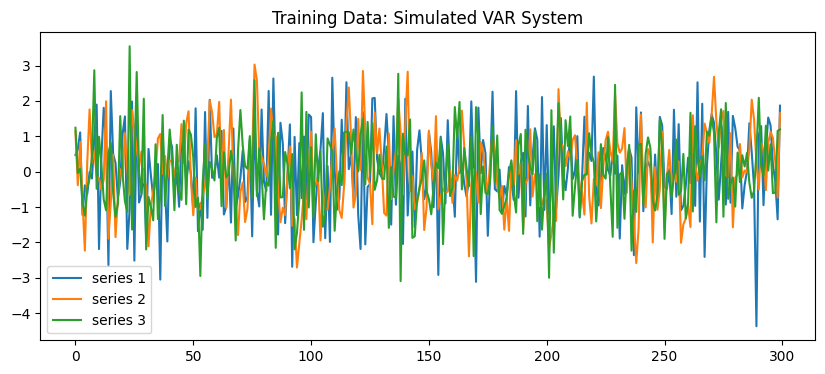

In [3]:
plt.figure(figsize=(10, 4))

for j in range(k):
    plt.plot(y_train[:, j], label=f"series {j+1}")

plt.title("Training Data: Simulated VAR System")
plt.legend()
plt.show()

In [4]:
fit = fit_var_ols(y_train, lags=lags)

residuals = fit["residuals"]
resid_mean = residuals.mean(axis=0)
resid_cov = np.cov(residuals.T)

print("Beta shape:", fit["beta"].shape)
print("Residuals shape:", residuals.shape)

print("\nResidual mean:")
print(resid_mean)

print("\nResidual covariance:")
print(resid_cov)

Beta shape: (4, 3)
Residuals shape: (299, 3)

Residual mean:
[-1.93082265e-17 -1.70803542e-17  9.65411326e-18]

Residual covariance:
[[1.0380374  0.25556766 0.10474496]
 [0.25556766 0.96001394 0.2540915 ]
 [0.10474496 0.2540915  1.0667745 ]]


In [5]:
print("Finite residuals:", np.all(np.isfinite(residuals)))
print("Finite residual mean:", np.all(np.isfinite(resid_mean)))
print("Finite residual cov:", np.all(np.isfinite(resid_cov)))
print("Residual cov eigenvalues:", np.linalg.eigvalsh(resid_cov))
print("Residual cov condition number:", np.linalg.cond(resid_cov))

Finite residuals: True
Finite residual mean: True
Finite residual cov: True
Residual cov eigenvalues: [0.68461561 0.94776755 1.43244268]
Residual cov condition number: 2.092331314254133


In [6]:
history = y_train[-lags:]

gaussian_shocks = sample_gaussian_innovations(
    mean=resid_mean,
    cov=resid_cov,
    n_paths=n_paths,
    horizon=horizon,
    seed=1,
)

bootstrap_shocks = sample_bootstrap_innovations(
    residuals=residuals,
    n_paths=n_paths,
    horizon=horizon,
    seed=2,
)

student_t_shocks = sample_student_t_innovations(
    mean=resid_mean,
    cov=resid_cov,
    df=5,
    n_paths=n_paths,
    horizon=horizon,
    seed=3,
)

print("Gaussian shocks:", gaussian_shocks.shape)
print("Bootstrap shocks:", bootstrap_shocks.shape)
print("Student-t shocks:", student_t_shocks.shape)

Gaussian shocks: (1000, 20, 3)
Bootstrap shocks: (1000, 20, 3)
Student-t shocks: (1000, 20, 3)


/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:18: RuntimeWarning: divide by zero encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:18: RuntimeWarning: overflow encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:18: RuntimeWarning: invalid value encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:23: RuntimeWarning: divide by zero encountered in matmul
  z = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:23: RuntimeWarning: overflow encountered in matmul
  z = rng.multivariate_normal(
/

In [7]:
gaussian_paths = simulate_var_forecast_paths(
    y_history=history,
    beta=fit["beta"],
    shocks=gaussian_shocks,
    lags=lags,
)

bootstrap_paths = simulate_var_forecast_paths(
    y_history=history,
    beta=fit["beta"],
    shocks=bootstrap_shocks,
    lags=lags,
)

student_t_paths = simulate_var_forecast_paths(
    y_history=history,
    beta=fit["beta"],
    shocks=student_t_shocks,
    lags=lags,
)

print("Gaussian paths:", gaussian_paths.shape)
print("Bootstrap paths:", bootstrap_paths.shape)
print("Student-t paths:", student_t_paths.shape)

Gaussian paths: (1000, 20, 3)
Bootstrap paths: (1000, 20, 3)
Student-t paths: (1000, 20, 3)


In [8]:
def summarize_forecast(name, paths, y_true):
    qs = forecast_path_quantiles(paths, quantiles=(0.05, 0.5, 0.95))

    lower = qs[0.05]
    median = qs[0.5]
    upper = qs[0.95]

    coverage = interval_coverage(y_true, lower, upper)
    width = average_interval_width(lower, upper)
    energy = mean_energy_score(paths, y_true)

    return {
        "model": name,
        "avg_coverage": coverage.mean(),
        "coverage_1": coverage[0],
        "coverage_2": coverage[1],
        "coverage_3": coverage[2],
        "avg_width": width.mean(),
        "width_1": width[0],
        "width_2": width[1],
        "width_3": width[2],
        "energy_score": energy,
        "lower": lower,
        "median": median,
        "upper": upper,
    }


gaussian_summary = summarize_forecast("Gaussian", gaussian_paths, y_test)
bootstrap_summary = summarize_forecast("Bootstrap", bootstrap_paths, y_test)
student_t_summary = summarize_forecast("Student-t", student_t_paths, y_test)

summary_df = pd.DataFrame([
    {k: v for k, v in gaussian_summary.items() if not isinstance(v, np.ndarray)},
    {k: v for k, v in bootstrap_summary.items() if not isinstance(v, np.ndarray)},
    {k: v for k, v in student_t_summary.items() if not isinstance(v, np.ndarray)},
])

summary_df

,model,avg_coverage,coverage_1,coverage_2,coverage_3,avg_width,width_1,width_2,width_3,energy_score
0,Gaussian,0.933333,0.9,1.0,0.9,3.667891,3.946737,3.532921,3.524013,1.225906
1,Bootstrap,0.933333,0.9,1.0,0.9,3.688885,3.954134,3.583937,3.528583,1.220385
2,Student-t,0.933333,0.9,1.0,0.9,4.586084,4.906085,4.421603,4.430563,1.231784


In [9]:
def plot_forecast_intervals(
    y_train,
    y_test,
    summary,
    variable=0,
    title="Forecast",
):
    n_train = len(y_train)
    horizon = len(y_test)

    x_train = np.arange(n_train)
    x_test = np.arange(n_train, n_train + horizon)

    lower = summary["lower"][:, variable]
    median = summary["median"][:, variable]
    upper = summary["upper"][:, variable]

    plt.figure(figsize=(11, 4))

    plt.plot(x_train, y_train[:, variable], label="train")
    plt.plot(x_test, y_test[:, variable], label="test")
    plt.plot(x_test, median, linestyle="--", label="median forecast")

    plt.fill_between(
        x_test,
        lower,
        upper,
        alpha=0.25,
        label="90% interval",
    )

    plt.title(title)
    plt.legend()
    plt.show()

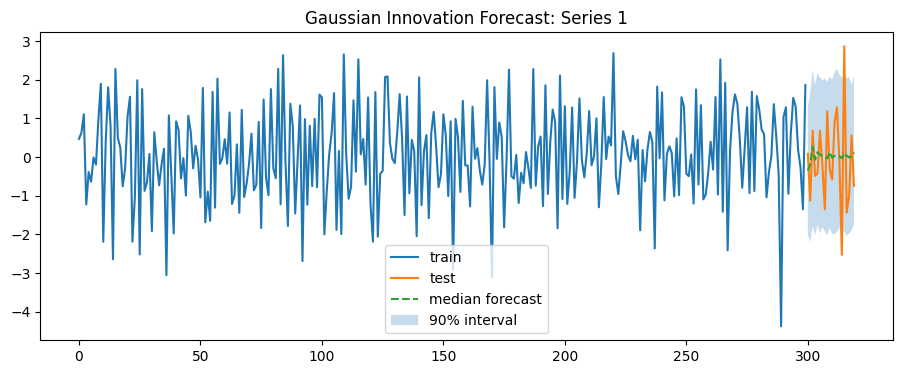

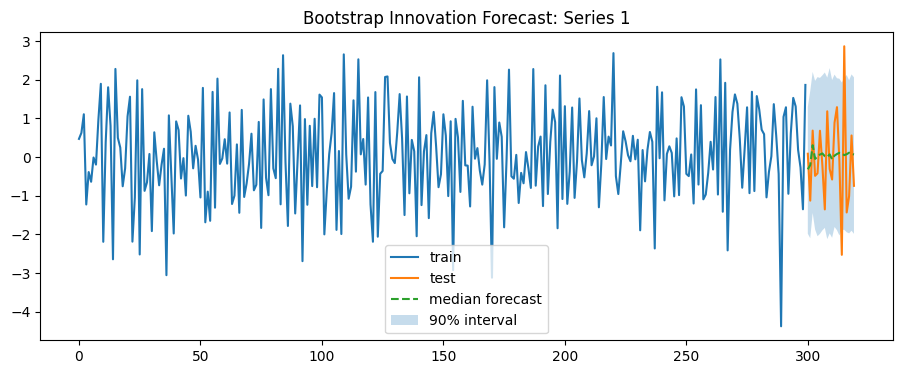

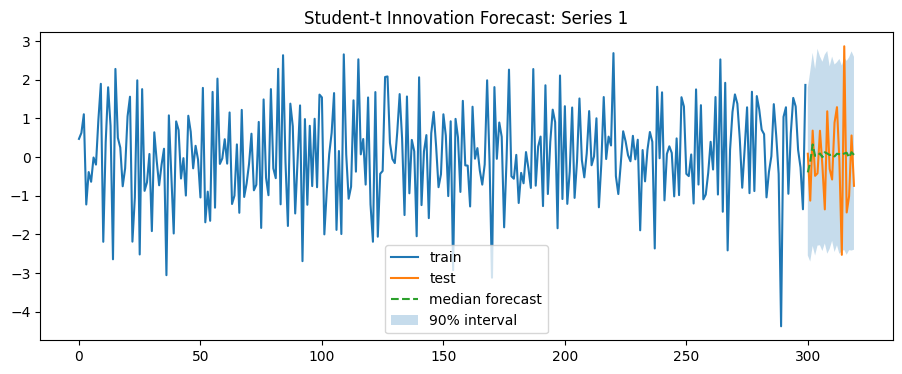

In [10]:
plot_forecast_intervals(
    y_train,
    y_test,
    gaussian_summary,
    variable=0,
    title="Gaussian Innovation Forecast: Series 1",
)

plot_forecast_intervals(
    y_train,
    y_test,
    bootstrap_summary,
    variable=0,
    title="Bootstrap Innovation Forecast: Series 1",
)

plot_forecast_intervals(
    y_train,
    y_test,
    student_t_summary,
    variable=0,
    title="Student-t Innovation Forecast: Series 1",
)